# 通用数据科学处理流程

本笔记本演示了完整的机器学习项目流程，包括：

1. **数据导入和基础分析**
2. **数据预处理和清洗**
3. **特征工程和编码**
4. **探索性数据分析 (EDA)**
5. **模型训练和比较**
6. **模型优化和评估**
7. **结果可视化和解释**

所有输出都使用中文显示，图表使用SimHei字体以确保中文正常显示。

In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [22]:
# 🔹 基础库
import numpy as np
import pandas as pd

# 🔹 数据可视化
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set_theme()

# 🔹 建模和评估
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 🔹 警告和可视化设置
import warnings
warnings.filterwarnings("ignore")
# 特别忽略lightgbm的警告
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
pd.set_option("display.max_columns", None)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# import missingno as msno        # 缺失数据可视化
import scipy.stats as stats     # 假设检验, p值等

import warnings
warnings.filterwarnings("ignore")  # 隐藏警告信息

pd.set_option("display.max_columns", None)  # 显示所有列

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

In [23]:
df=pd.read_csv('health/health_lifestyle_classification.csv')
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [24]:
df.isnull().sum()

survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support           0
education_leve

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

In [26]:
df.shape

(100000, 48)

In [27]:
df.duplicated().sum()

0

In [28]:
cat_cols = [col for col in df.columns if df[col].dtype == "O"]
num_cols = [col for col in df.columns if df[col].dtype != "O" and col != "target"]
bool_cols = [col for col in df.columns if df[col].dtype == "bool"]

print("分类变量:", cat_cols)
print("数值变量:", num_cols)

分类变量: ['gender', 'sleep_quality', 'alcohol_consumption', 'smoking_level', 'mental_health_support', 'education_level', 'job_type', 'occupation', 'diet_type', 'exercise_type', 'device_usage', 'healthcare_access', 'insurance', 'sunlight_exposure', 'caffeine_intake', 'family_history', 'pet_owner', 'target']
数值变量: ['survey_code', 'age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled', 'bmi_corrected', 'waist_size', 'blood_pressure', 'heart_rate', 'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'work_hours', 'physical_activity', 'daily_steps', 'calorie_intake', 'sugar_intake', 'water_intake', 'screen_time', 'stress_level', 'mental_health_score', 'income', 'meals_per_day', 'electrolyte_level', 'gene_marker_flag', 'environmental_risk_score', 'daily_supplement_dosage']


count    100000.000000
mean      50000.500000
std       28867.657797
min           1.000000
25%       25000.750000
50%       50000.500000
75%       75000.250000
max      100000.000000
Name: survey_code, dtype: float64


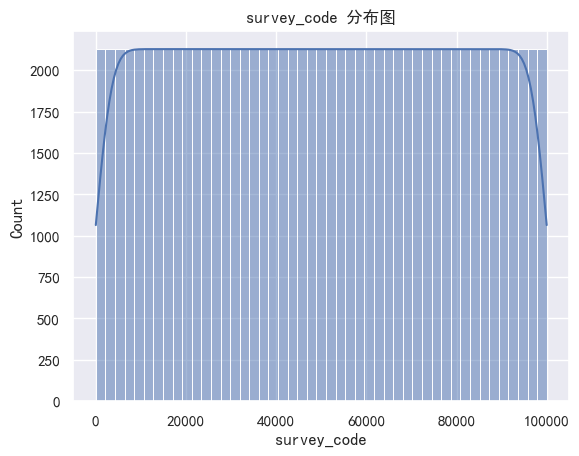

count    100000.000000
mean         48.525990
std          17.886768
min          18.000000
25%          33.000000
50%          48.000000
75%          64.000000
max          79.000000
Name: age, dtype: float64


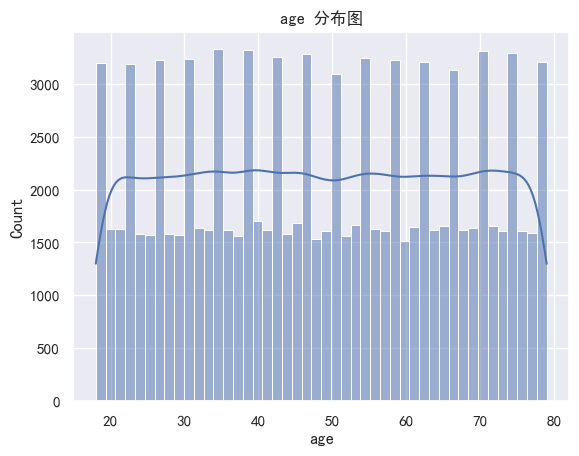

count    100000.000000
mean        170.023707
std           9.982798
min         140.000000
25%         163.306615
50%         170.016778
75%         176.728920
max         210.000000
Name: height, dtype: float64


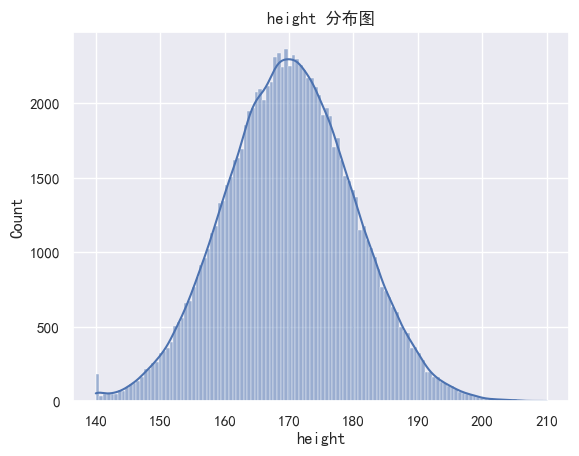

count    100000.000000
mean         70.064862
std          14.693667
min          40.000000
25%          59.856938
50%          69.924141
75%          80.027418
max         139.250894
Name: weight, dtype: float64


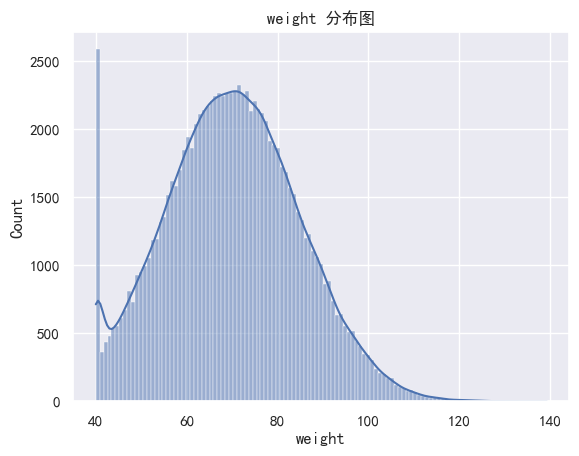

count    100000.000000
mean         24.493876
std           5.951069
min           9.988495
25%          20.271405
50%          24.156734
75%          28.258696
max          59.234792
Name: bmi, dtype: float64


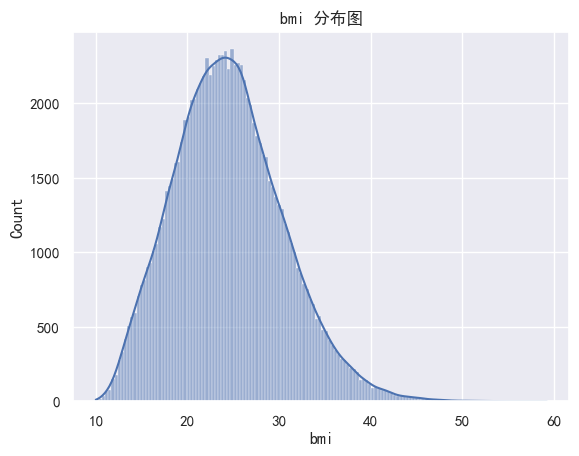

count    100000.000000
mean         24.493876
std           5.951069
min           9.988495
25%          20.271405
50%          24.156734
75%          28.258696
max          59.234792
Name: bmi_estimated, dtype: float64


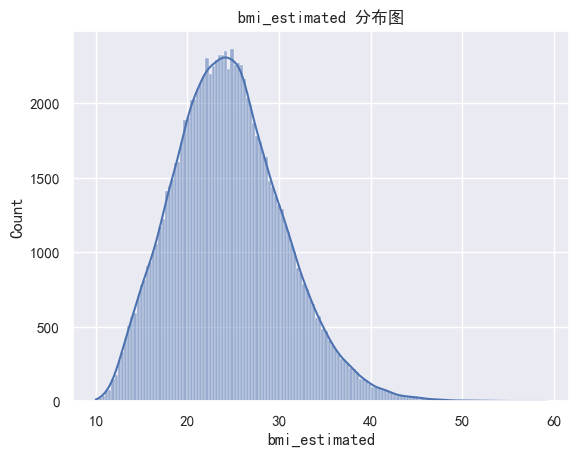

count    100000.000000
mean         73.481627
std          17.853206
min          29.965484
25%          60.814215
50%          72.470201
75%          84.776088
max         177.704377
Name: bmi_scaled, dtype: float64


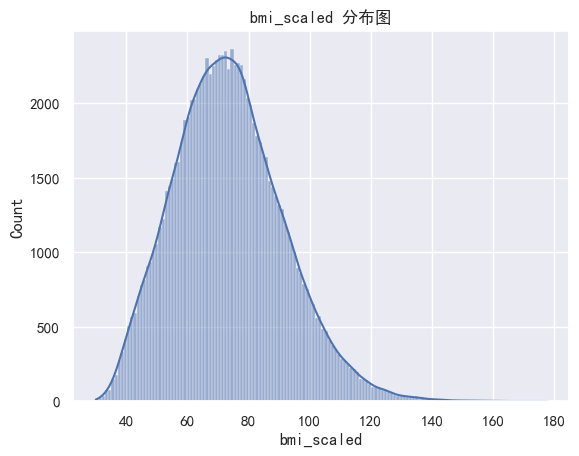

count    100000.000000
mean         24.494140
std           5.954184
min           9.893845
25%          20.271059
50%          24.151699
75%          28.247648
max          59.142646
Name: bmi_corrected, dtype: float64


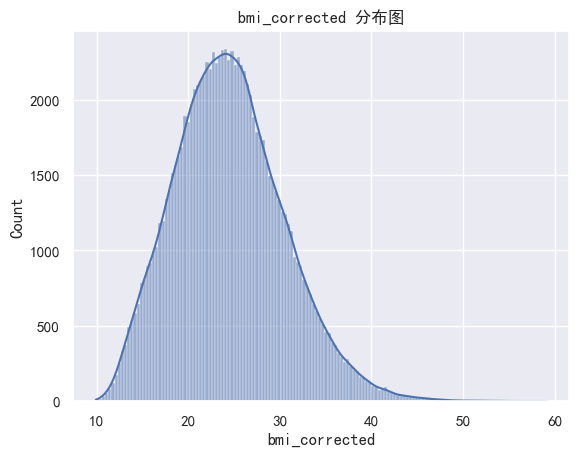

count    100000.000000
mean         84.933043
std          12.040314
min          34.093185
25%          76.795185
50%          84.957139
75%          93.018713
max         133.153631
Name: waist_size, dtype: float64


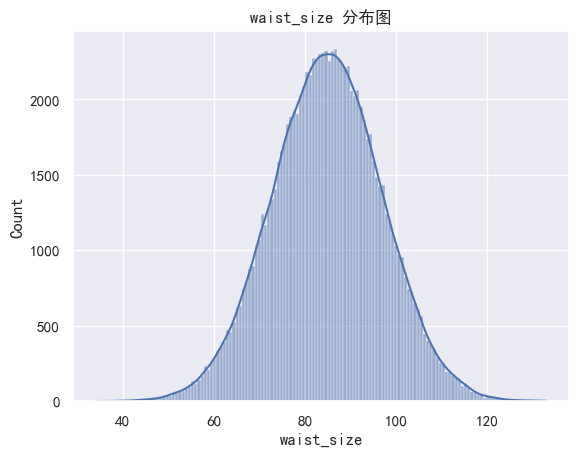

count    92331.000000
mean       119.980149
std         15.015503
min         59.128168
25%        109.812060
50%        119.951794
75%        130.120621
max        184.439195
Name: blood_pressure, dtype: float64


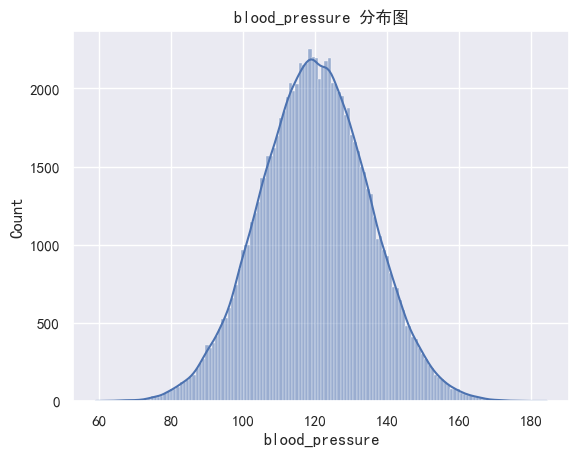

count    85997.000000
mean        74.969177
std          9.941668
min         34.745092
25%         68.275432
50%         75.046211
75%         81.685914
max        114.136041
Name: heart_rate, dtype: float64


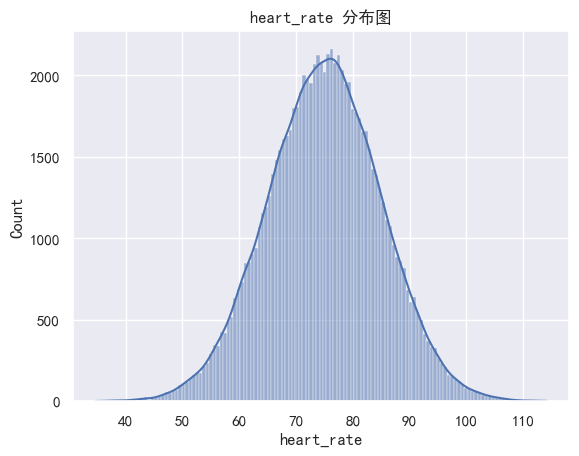

count    100000.000000
mean        189.966438
std          29.981934
min          58.410902
25%         169.667738
50%         190.044579
75%         210.222005
max         319.875613
Name: cholesterol, dtype: float64


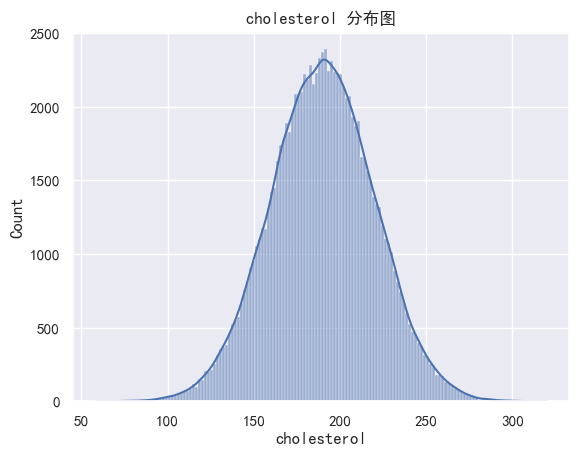

count    100000.000000
mean         99.994538
std          19.982828
min          12.434931
25%          86.461401
50%          99.986834
75%         113.508722
max         183.883548
Name: glucose, dtype: float64


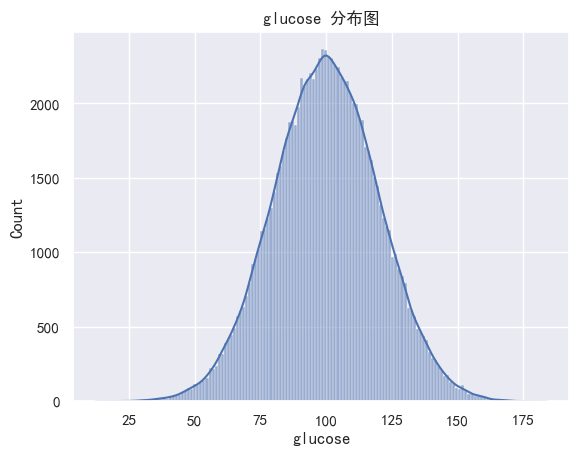

count    84164.000000
mean        14.988258
std          5.002783
min         -6.794483
25%         11.627114
50%         14.983414
75%         18.361928
max         35.464749
Name: insulin, dtype: float64


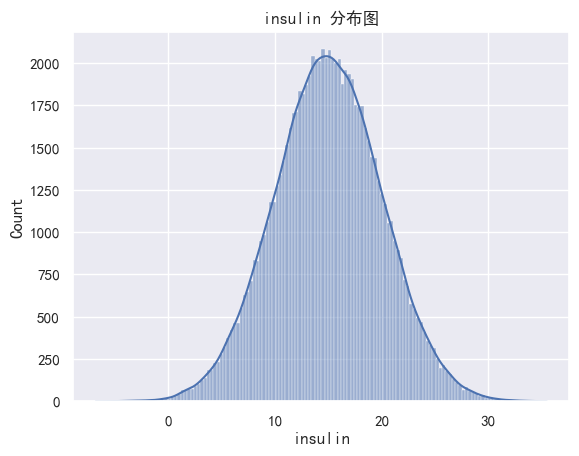

count    100000.000000
mean          7.002008
std           1.496821
min           3.000000
25%           5.986781
50%           6.998164
75%           8.019219
max          12.000000
Name: sleep_hours, dtype: float64


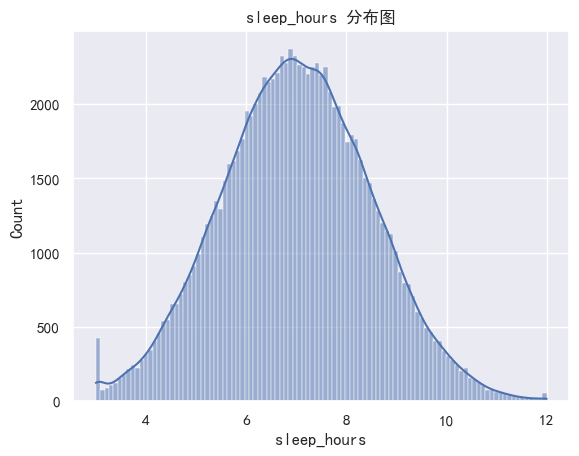

count    100000.000000
mean          8.001331
std           1.994723
min           0.000000
25%           6.651093
50%           8.004549
75%           9.353669
max          16.000000
Name: work_hours, dtype: float64


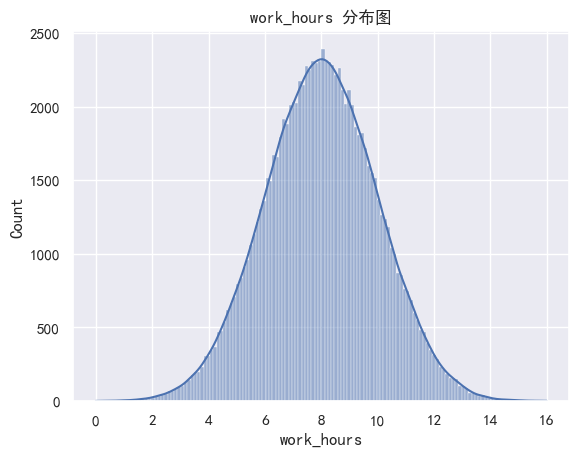

count    100000.000000
mean          3.038344
std           1.884475
min           0.000000
25%           1.633799
50%           2.971222
75%           4.326500
max          11.631898
Name: physical_activity, dtype: float64


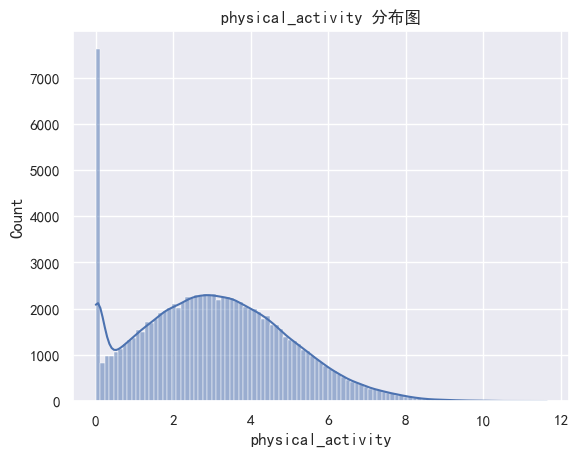

count    91671.000000
mean      7012.925748
std       2488.989356
min       1000.000000
25%       5320.858377
50%       7004.285450
75%       8702.281300
max      18064.969543
Name: daily_steps, dtype: float64


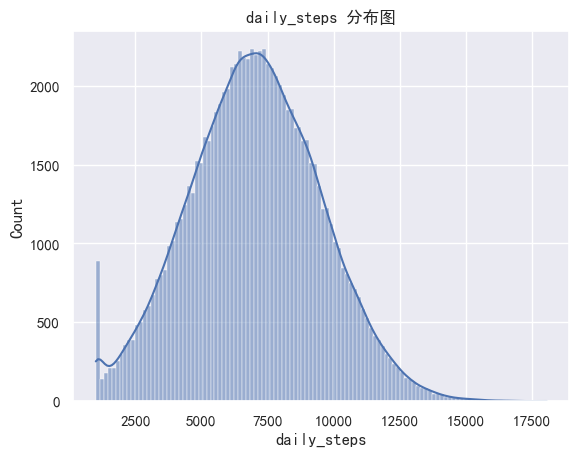

count    100000.000000
mean       2201.428579
std         400.516318
min         527.172360
25%        1932.278165
50%        2200.992765
75%        2471.218160
max        3949.019017
Name: calorie_intake, dtype: float64


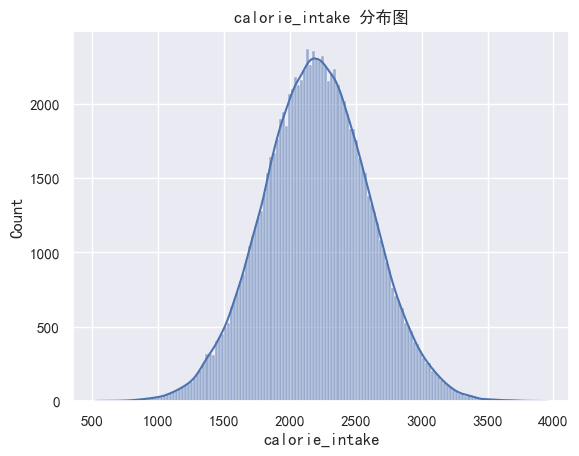

count    100000.000000
mean         60.047165
std          19.966850
min         -27.882444
25%          46.504292
50%          60.047905
75%          73.476386
max         141.514522
Name: sugar_intake, dtype: float64


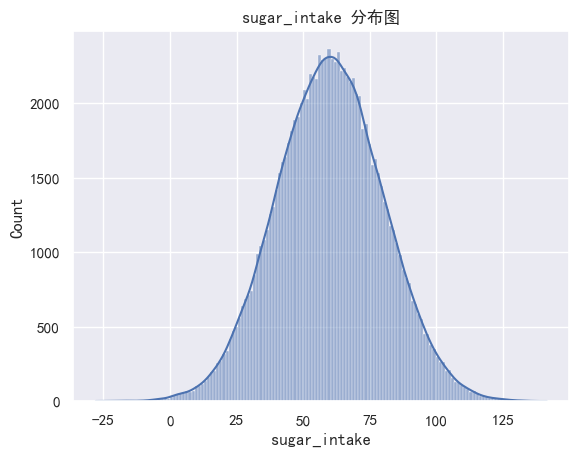

count    100000.000000
mean          2.006373
std           0.688868
min           0.500000
25%           1.532011
50%           2.000659
75%           2.473047
max           5.000000
Name: water_intake, dtype: float64


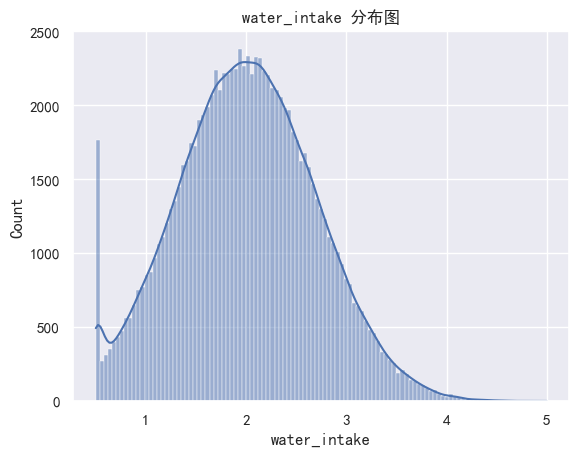

count    100000.000000
mean          6.021525
std           2.933835
min           0.000000
25%           3.971318
50%           5.991171
75%           8.024470
max          16.000000
Name: screen_time, dtype: float64


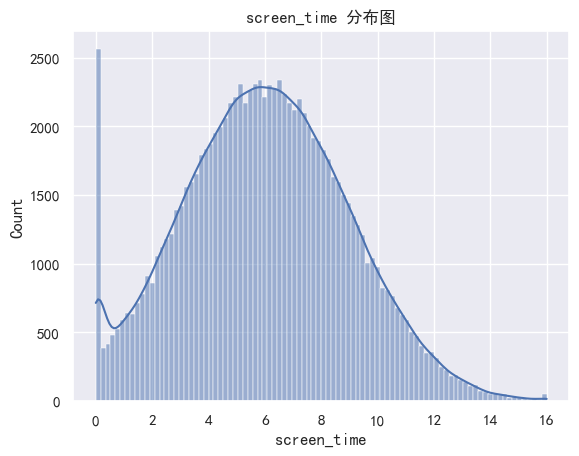

count    100000.000000
mean          4.991600
std           3.154997
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: stress_level, dtype: float64


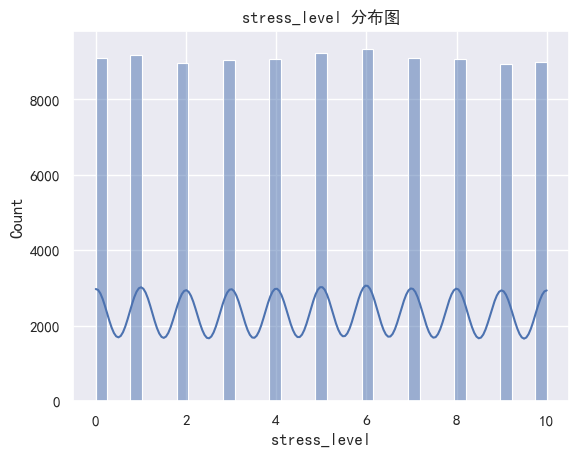

count    100000.000000
mean          5.004680
std           3.164228
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: mental_health_score, dtype: float64


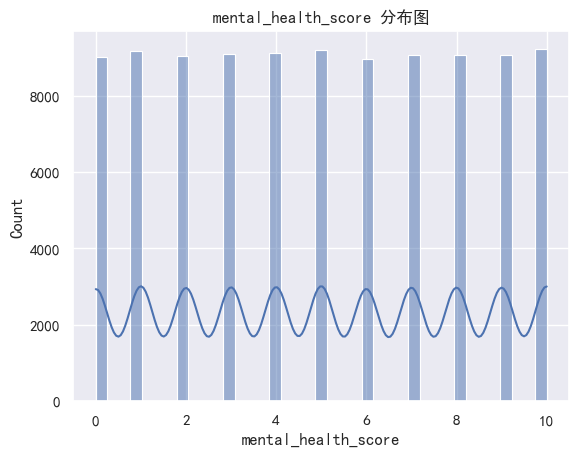

count    91530.000000
mean      4038.127284
std       1930.025678
min        500.000000
25%       2665.402843
50%       4004.601345
75%       5360.012694
max      12029.409353
Name: income, dtype: float64


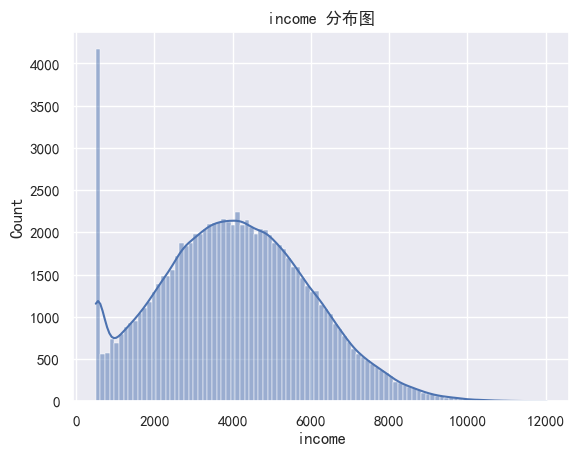

count    100000.000000
mean          2.998720
std           1.414786
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: meals_per_day, dtype: float64


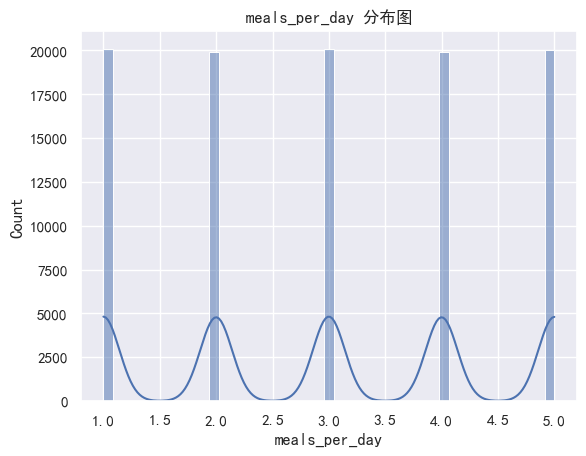

count    100000.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: electrolyte_level, dtype: float64


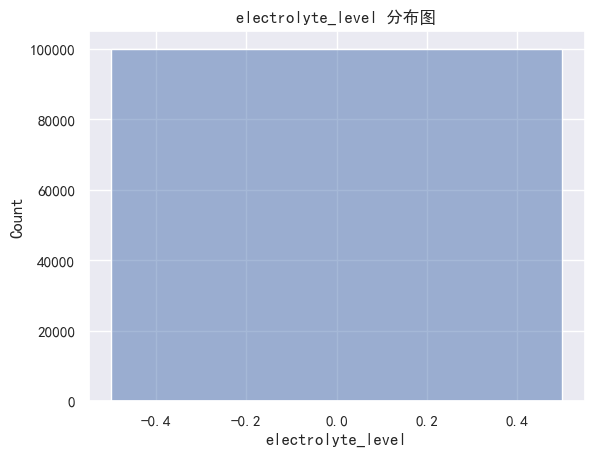

count    89526.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: gene_marker_flag, dtype: float64


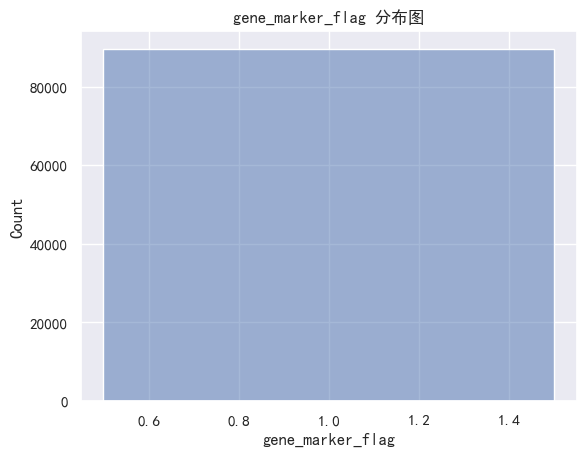

count    100000.0
mean          5.5
std           0.0
min           5.5
25%           5.5
50%           5.5
75%           5.5
max           5.5
Name: environmental_risk_score, dtype: float64


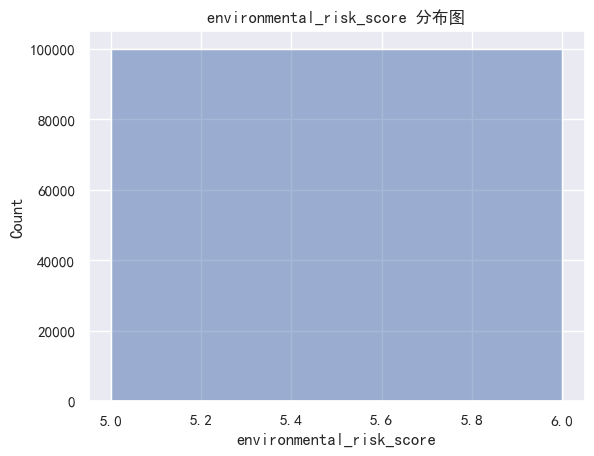

count    100000.000000
mean          0.015726
std           5.764489
min          -9.999895
25%          -4.980501
50%           0.015589
75%           5.008424
max           9.999966
Name: daily_supplement_dosage, dtype: float64


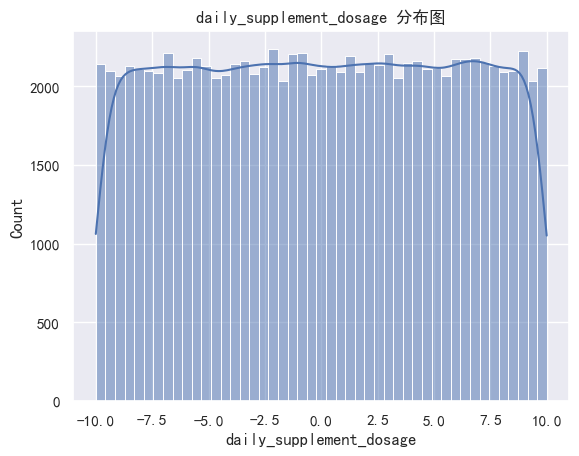

In [29]:
def summary_numeric(col):
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} 分布图")
    plt.show()

for col in num_cols:
    summary_numeric(col)

In [30]:
def outlier_thresholds(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def check_outliers(data, col):
    lower, upper = outlier_thresholds(data, col)
    return data[(data[col] < lower) | (data[col] > upper)]

for col in num_cols:
    print(f"{col} 异常值数量:", len(check_outliers(df, col)))

survey_code 异常值数量: 0
age 异常值数量: 0
height 异常值数量: 750
weight 异常值数量: 335
bmi 异常值数量: 936
bmi_estimated 异常值数量: 936
bmi_scaled 异常值数量: 936
bmi_corrected 异常值数量: 937
waist_size 异常值数量: 706
blood_pressure 异常值数量: 591
heart_rate 异常值数量: 612
cholesterol 异常值数量: 677
glucose 异常值数量: 680
insulin 异常值数量: 571
sleep_hours 异常值数量: 326
work_hours 异常值数量: 618
physical_activity 异常值数量: 341
daily_steps 异常值数量: 307
calorie_intake 异常值数量: 730
sugar_intake 异常值数量: 688
water_intake 异常值数量: 348
screen_time 异常值数量: 339
stress_level 异常值数量: 0
mental_health_score 异常值数量: 0
income 异常值数量: 315
meals_per_day 异常值数量: 0
electrolyte_level 异常值数量: 0
gene_marker_flag 异常值数量: 0
environmental_risk_score 异常值数量: 0
daily_supplement_dosage 异常值数量: 0


In [31]:
def replace_outliers_with_median(data, col):
    lower, upper = outlier_thresholds(data, col)
    median = data[col].median()
    data[col] = np.where((data[col] < lower) | (data[col] > upper), median, data[col])

for col in num_cols:
    replace_outliers_with_median(df, col)

In [32]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

for col in df.select_dtypes(include=['int64', 'float64']):
    df[col].fillna(df[col].median(), inplace=True)

count    100000.000000
mean      50000.500000
std       28867.657797
min           1.000000
25%       25000.750000
50%       50000.500000
75%       75000.250000
max      100000.000000
Name: survey_code, dtype: float64


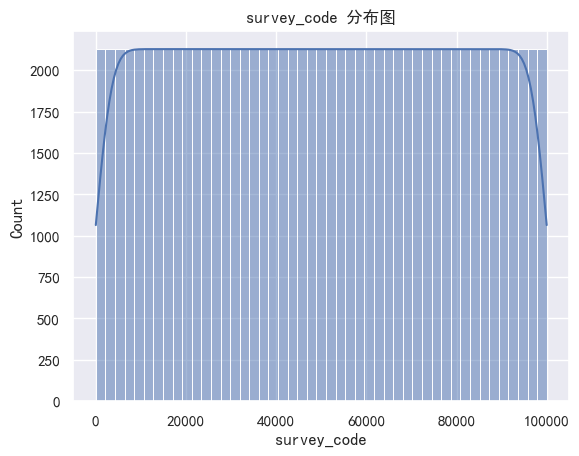

count    100000.000000
mean         48.525990
std          17.886768
min          18.000000
25%          33.000000
50%          48.000000
75%          64.000000
max          79.000000
Name: age, dtype: float64


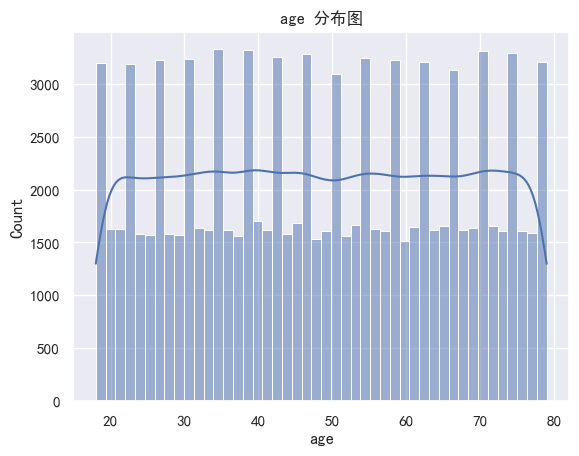

count    100000.000000
mean        170.030716
std           9.648916
min         143.177643
25%         163.423441
50%         170.016778
75%         176.615234
max         196.854326
Name: height, dtype: float64


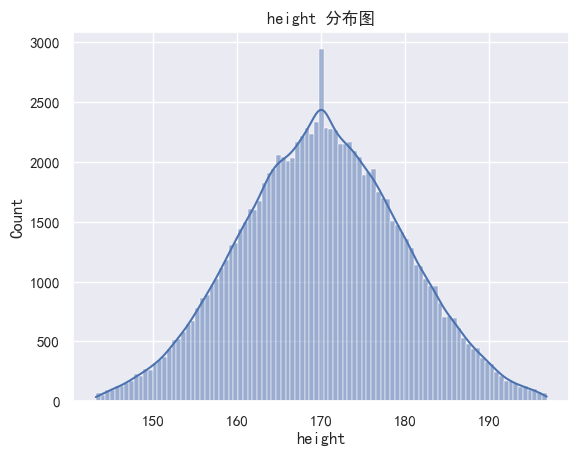

count    100000.000000
mean         69.913677
std          14.458149
min          40.000000
25%          59.856938
50%          69.923976
75%          79.874108
max         110.277510
Name: weight, dtype: float64


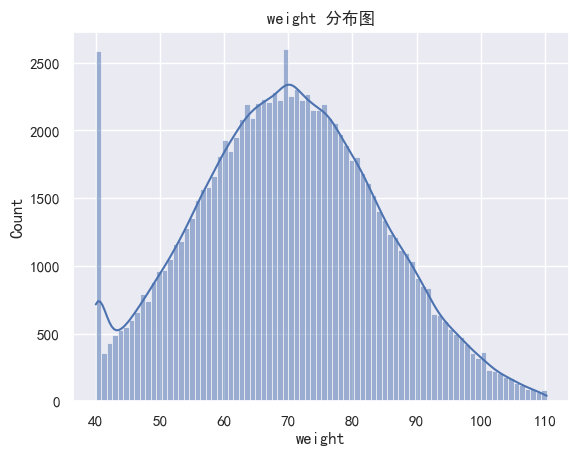

count    100000.000000
mean         24.316338
std           5.662509
min           9.988495
25%          20.271405
50%          24.156661
75%          28.073942
max          40.238257
Name: bmi, dtype: float64


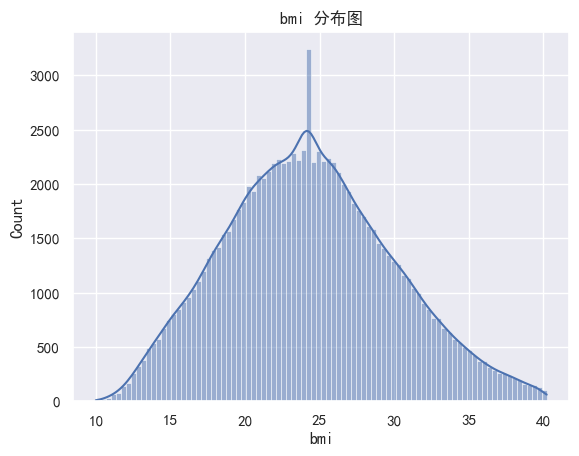

count    100000.000000
mean         24.316338
std           5.662509
min           9.988495
25%          20.271405
50%          24.156661
75%          28.073942
max          40.238257
Name: bmi_estimated, dtype: float64


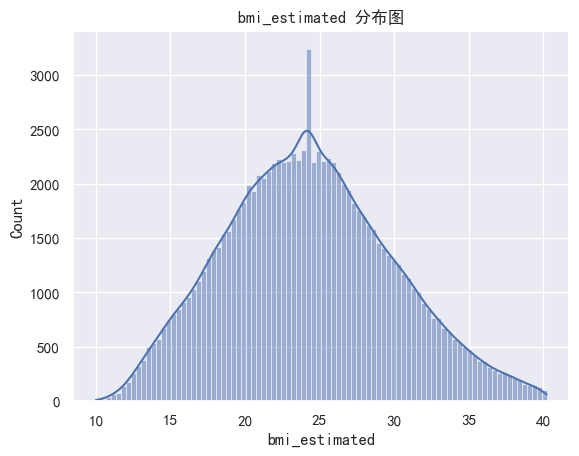

count    100000.000000
mean         72.949013
std          16.987527
min          29.965484
25%          60.814215
50%          72.469982
75%          84.221826
max         120.714770
Name: bmi_scaled, dtype: float64


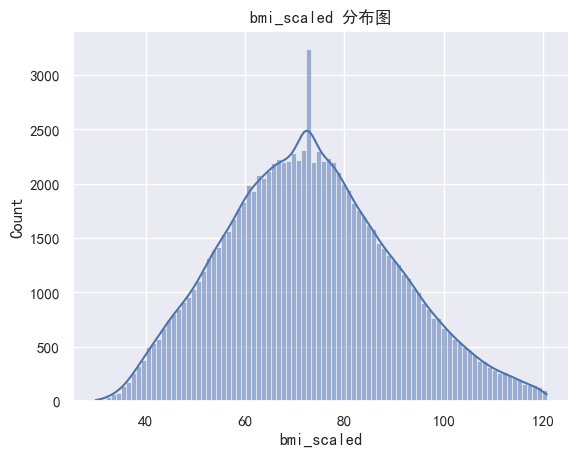

count    100000.000000
mean         24.316307
std           5.665276
min           9.893845
25%          20.271059
50%          24.151611
75%          28.069976
max          40.210679
Name: bmi_corrected, dtype: float64


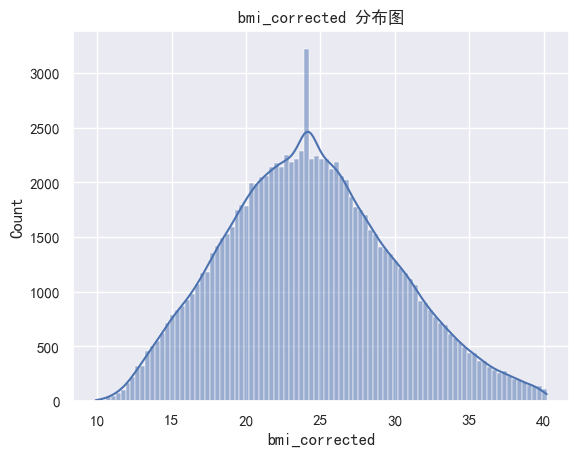

count    100000.000000
mean         84.938193
std          11.648073
min          52.460818
25%          76.944118
50%          84.957139
75%          92.889565
max         117.350587
Name: waist_size, dtype: float64


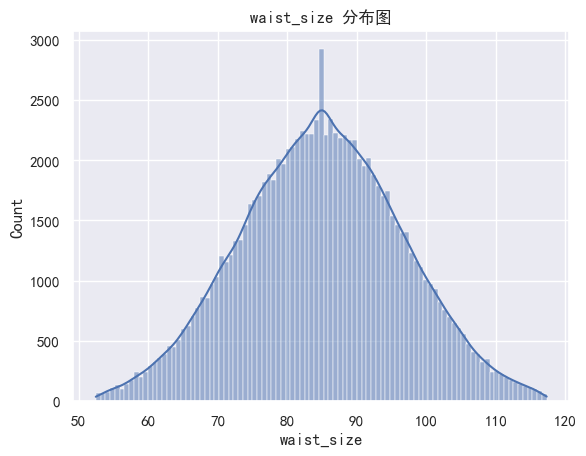

count    100000.000000
mean        119.963416
std          14.003740
min          79.354041
25%         110.937887
50%         119.951794
75%         129.027823
max         160.579138
Name: blood_pressure, dtype: float64


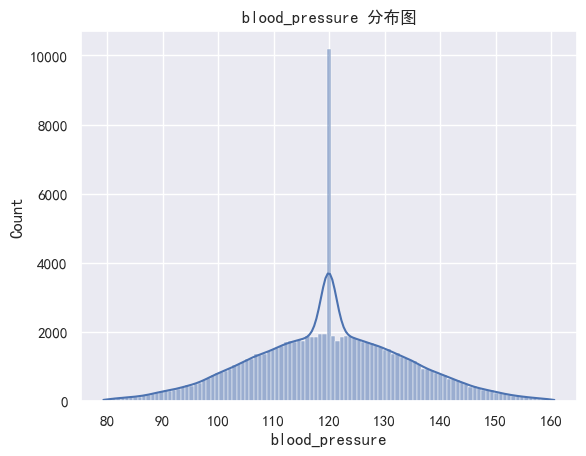

count    100000.000000
mean         74.983850
std           8.917839
min          48.165531
25%          69.651925
50%          75.046211
75%          80.368872
max         101.796722
Name: heart_rate, dtype: float64


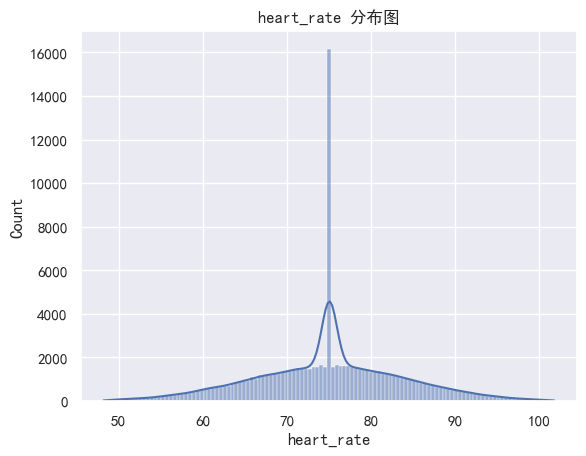

count    100000.000000
mean        190.000458
std          29.037190
min         108.877883
25%         170.020396
50%         190.044579
75%         209.923885
max         271.051076
Name: cholesterol, dtype: float64


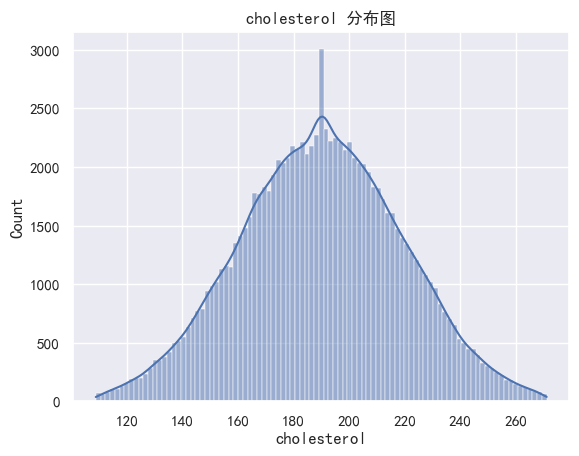

count    100000.000000
mean        100.013416
std          19.354002
min          45.936476
25%          86.666975
50%          99.986834
75%         113.288103
max         154.072129
Name: glucose, dtype: float64


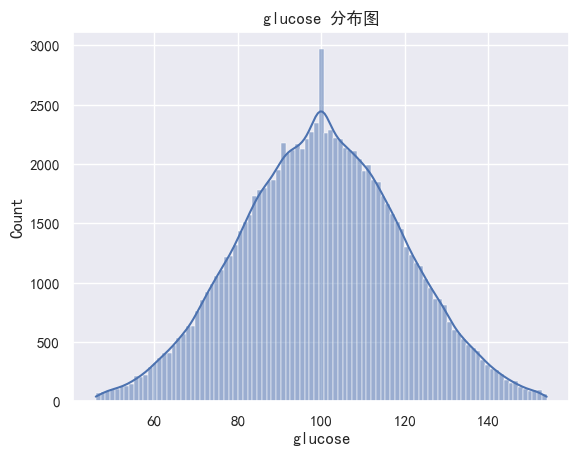

count    100000.000000
mean         14.985058
std           4.447617
min           1.532953
25%          12.370439
50%          14.983414
75%          17.607068
max          28.459451
Name: insulin, dtype: float64


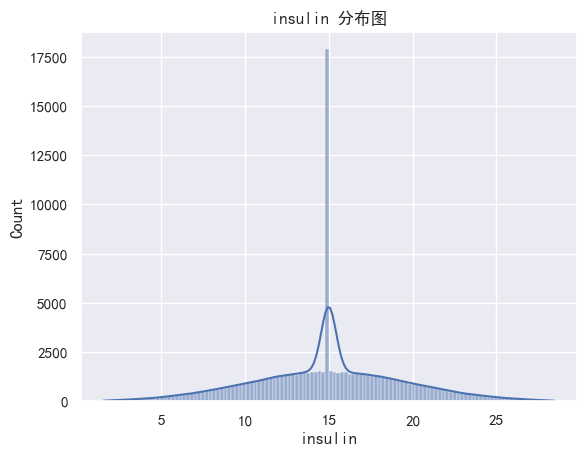

count    100000.000000
mean          6.987423
std           1.474725
min           3.000000
25%           5.986781
50%           6.998117
75%           8.004414
max          11.066937
Name: sleep_hours, dtype: float64


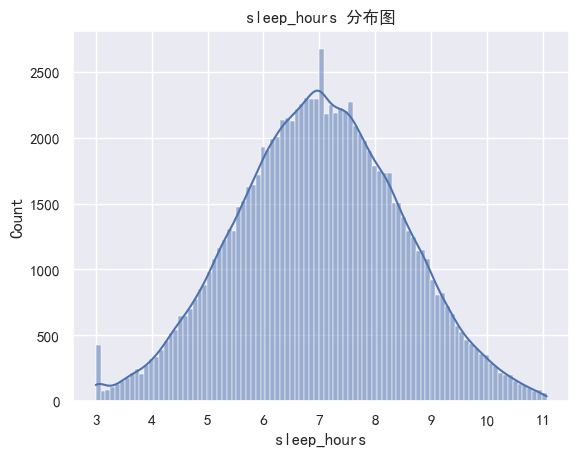

count    100000.000000
mean          8.003269
std           1.937305
min           2.598396
25%           6.671214
50%           8.004549
75%           9.336109
max          13.402927
Name: work_hours, dtype: float64


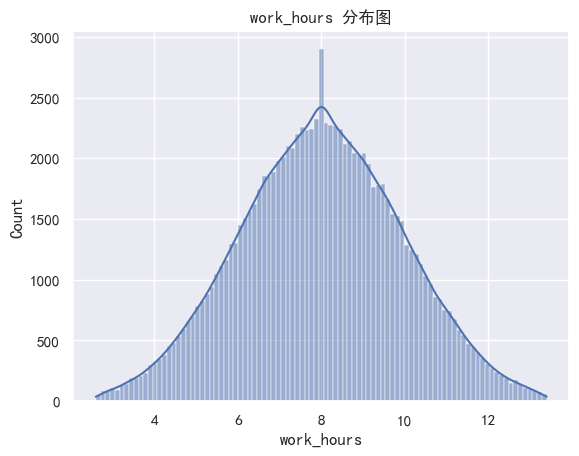

count    100000.000000
mean          3.017690
std           1.851302
min           0.000000
25%           1.633799
50%           2.971195
75%           4.304298
max           8.362492
Name: physical_activity, dtype: float64


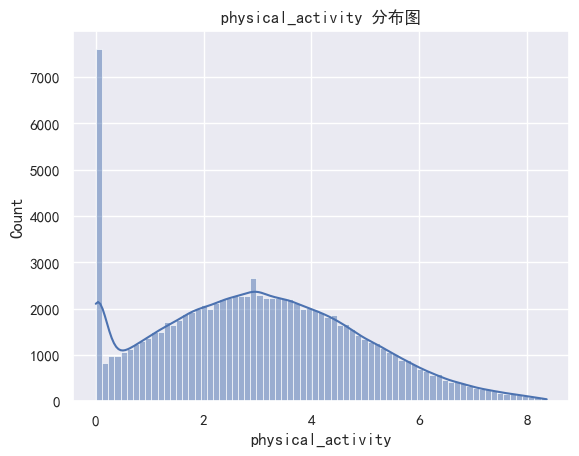

count    100000.000000
mean       6989.005312
std        2345.668013
min        1000.000000
25%        5500.327842
50%        7004.285450
75%        8497.005504
max       13773.038113
Name: daily_steps, dtype: float64


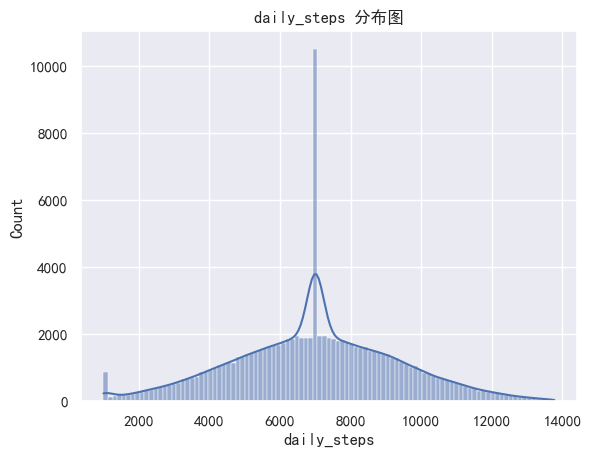

count    100000.000000
mean       2201.638895
std         386.855037
min        1124.783322
25%        1936.596743
50%        2200.992765
75%        2466.484939
max        3279.443961
Name: calorie_intake, dtype: float64


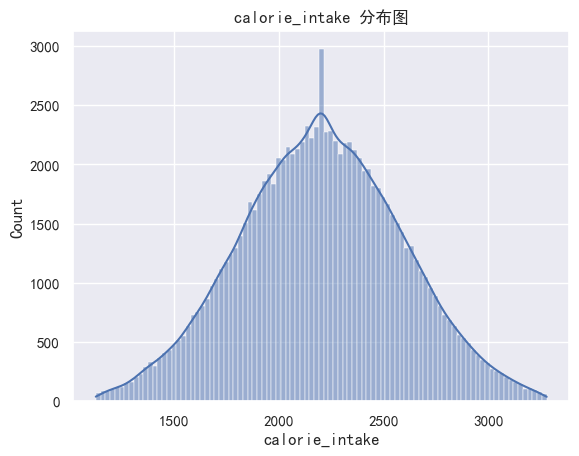

count    100000.000000
mean         60.066151
std          19.335342
min           6.060452
25%          46.731458
50%          60.047905
75%          73.283817
max         113.909670
Name: sugar_intake, dtype: float64


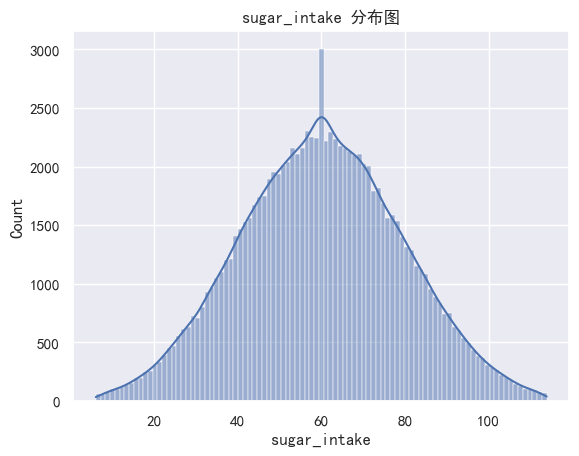

count    100000.000000
mean          1.999058
std           0.677528
min           0.500000
25%           1.532011
50%           2.000656
75%           2.465253
max           3.883588
Name: water_intake, dtype: float64


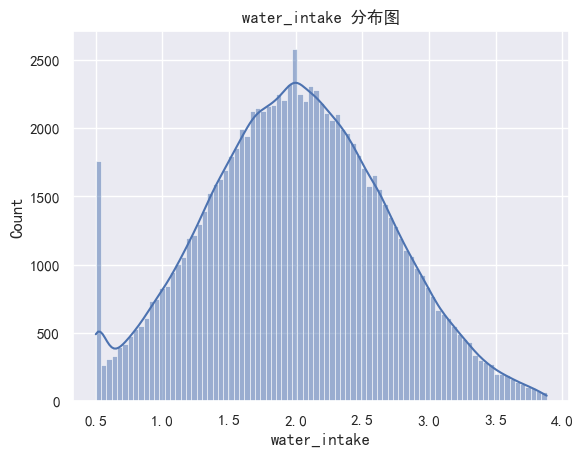

count    100000.000000
mean          5.991273
std           2.887393
min           0.000000
25%           3.971318
50%           5.991168
75%           7.990276
max          14.103687
Name: screen_time, dtype: float64


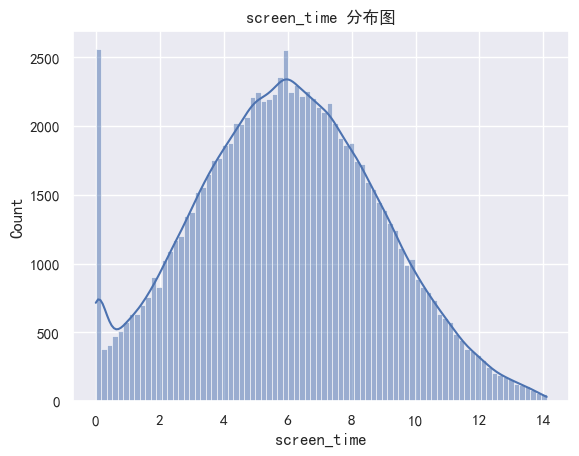

count    100000.000000
mean          4.991600
std           3.154997
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: stress_level, dtype: float64


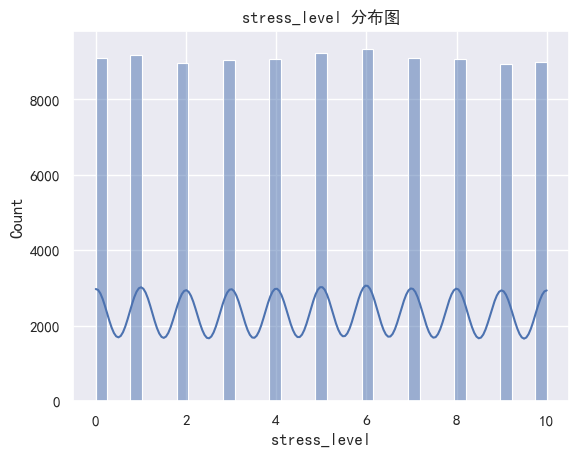

count    100000.000000
mean          5.004680
std           3.164228
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: mental_health_score, dtype: float64


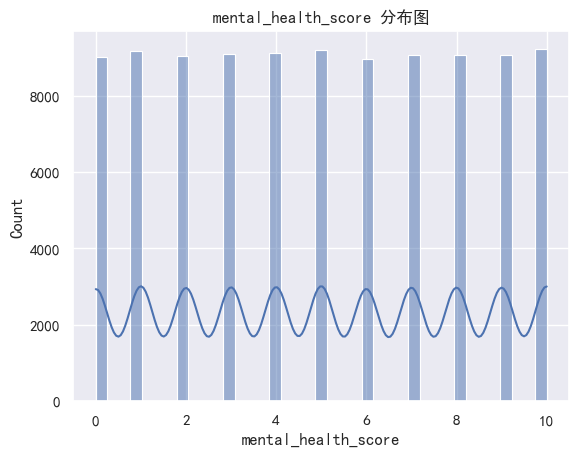

count    100000.000000
mean       4016.401207
std        1815.565764
min         500.000000
25%        2796.061969
50%        4004.599415
75%        5200.229838
max        9401.378393
Name: income, dtype: float64


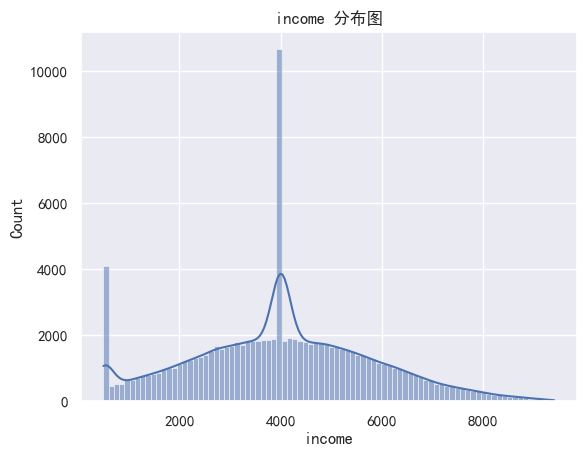

count    100000.000000
mean          2.998720
std           1.414786
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: meals_per_day, dtype: float64


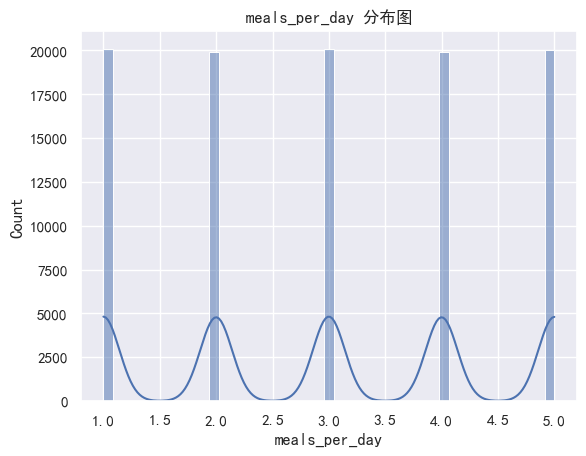

count    100000.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: electrolyte_level, dtype: float64


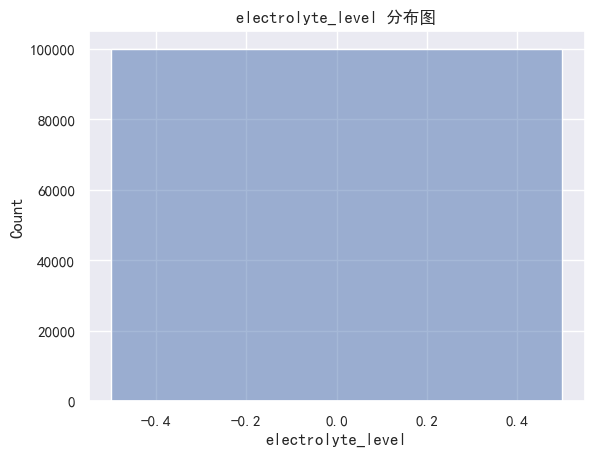

count    100000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: gene_marker_flag, dtype: float64


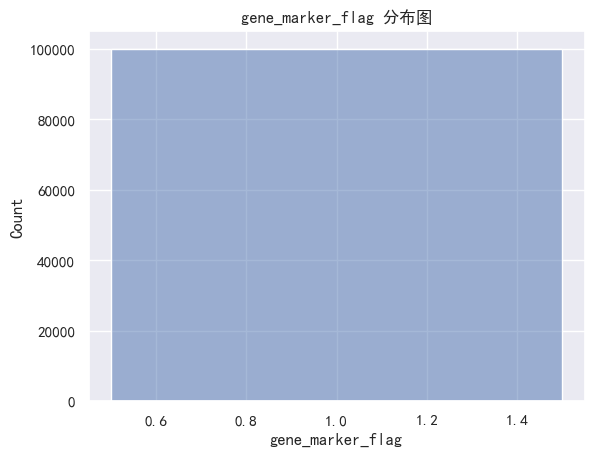

count    100000.0
mean          5.5
std           0.0
min           5.5
25%           5.5
50%           5.5
75%           5.5
max           5.5
Name: environmental_risk_score, dtype: float64


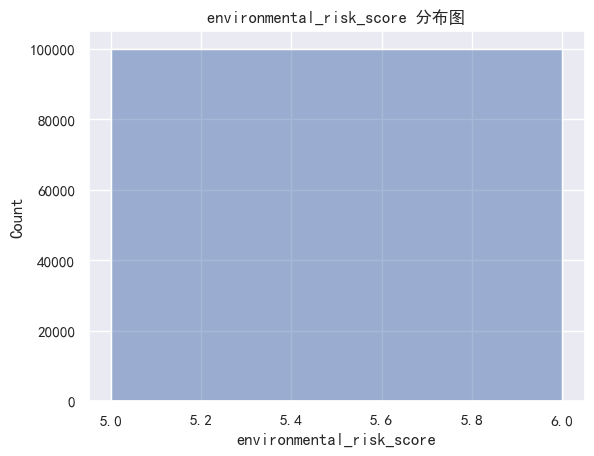

count    100000.000000
mean          0.015726
std           5.764489
min          -9.999895
25%          -4.980501
50%           0.015589
75%           5.008424
max           9.999966
Name: daily_supplement_dosage, dtype: float64


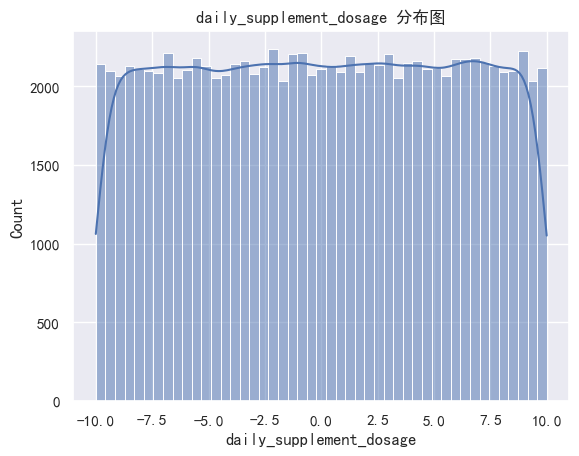

In [33]:
def summary_numeric(col):
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} 分布图")
    plt.show()

for col in num_cols:
    summary_numeric(col)

In [34]:
df.isnull().sum()

survey_code                 0
age                         0
gender                      0
height                      0
weight                      0
bmi                         0
bmi_estimated               0
bmi_scaled                  0
bmi_corrected               0
waist_size                  0
blood_pressure              0
heart_rate                  0
cholesterol                 0
glucose                     0
insulin                     0
sleep_hours                 0
sleep_quality               0
work_hours                  0
physical_activity           0
daily_steps                 0
calorie_intake              0
sugar_intake                0
alcohol_consumption         0
smoking_level               0
water_intake                0
screen_time                 0
stress_level                0
mental_health_score         0
mental_health_support       0
education_level             0
job_type                    0
occupation                  0
income                      0
diet_type 

In [35]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    """
    对分类列进行编码处理
    - 二分类变量：使用标签编码
    - 多分类变量：使用独热编码并转换为整数类型
    """

    label_encoder = LabelEncoder()

    for col in df.select_dtypes(include=['object', 'category']).columns:
        unique_vals = df[col].nunique()

        if unique_vals == 2:
            # 标签编码
            df[col] = label_encoder.fit_transform(df[col])
        elif unique_vals > 2:
            # 独热编码 + 从布尔值转换为整数
            dummies = pd.get_dummies(df[col], prefix=col).astype(int)
            df = pd.concat([df.drop(col, axis=1), dummies], axis=1)

    return df

In [36]:
df = encode_categorical_columns(df)

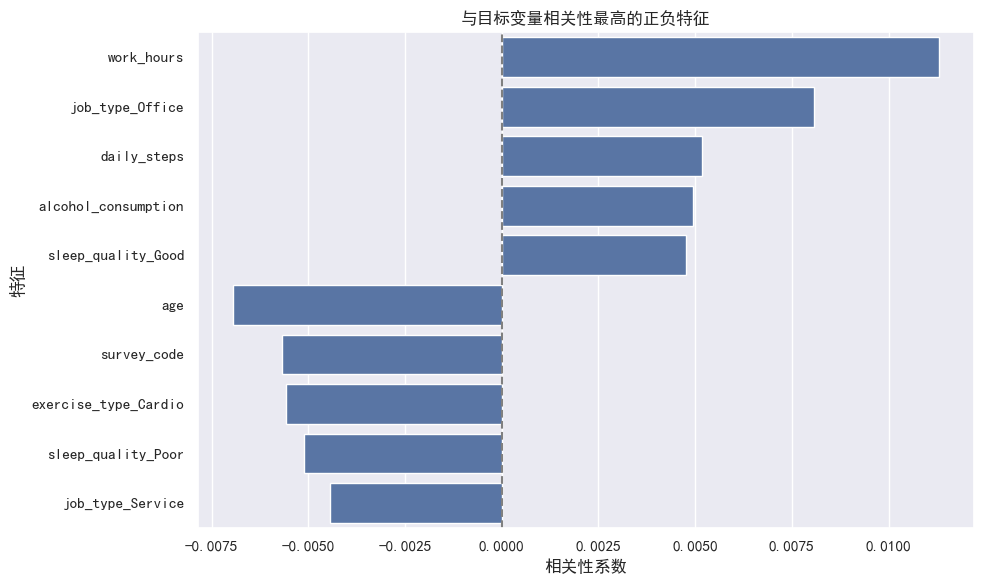

In [37]:
# 只选择数值列
numeric_df = df.select_dtypes(include='number')

# 获取相关性矩阵
corr_matrix = numeric_df.corr()

# 只获取与目标变量的相关性，排除自身
target_corr = corr_matrix['target'].drop('target')

# 选择最高的正相关和负相关（各5个）
top_5_positive = target_corr.sort_values(ascending=False).head(5)
top_5_negative = target_corr.sort_values().head(5)

# 合并
top_corr_features = pd.concat([top_5_positive, top_5_negative])

# 可视化
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index)
plt.title("与目标变量相关性最高的正负特征")
plt.xlabel("相关性系数")
plt.ylabel("特征")
plt.axvline(0, color='gray', linestyle='--')  # 0线
plt.tight_layout()
plt.show()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 77 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   survey_code                  100000 non-null  float64
 1   age                          100000 non-null  float64
 2   gender                       100000 non-null  int32  
 3   height                       100000 non-null  float64
 4   weight                       100000 non-null  float64
 5   bmi                          100000 non-null  float64
 6   bmi_estimated                100000 non-null  float64
 7   bmi_scaled                   100000 non-null  float64
 8   bmi_corrected                100000 non-null  float64
 9   waist_size                   100000 non-null  float64
 10  blood_pressure               100000 non-null  float64
 11  heart_rate                   100000 non-null  float64
 12  cholesterol                  100000 non-null  float64
 13  

📊 模型比较结果:
         模型       准确率       精确率       召回率      F1分数
5     支持向量机  0.982456  0.972603  1.000000  0.986111
0      逻辑回归  0.973684  0.972222  0.985915  0.979021
8  CatBoost  0.973684  0.972222  0.985915  0.979021
1      随机森林  0.964912  0.958904  0.985915  0.972222
4     朴素贝叶斯  0.964912  0.958904  0.985915  0.972222
7  LightGBM  0.964912  0.958904  0.985915  0.972222
2      梯度提升  0.956140  0.958333  0.971831  0.965035
6   XGBoost  0.956140  0.958333  0.971831  0.965035
3       决策树  0.938596  0.957143  0.943662  0.950355


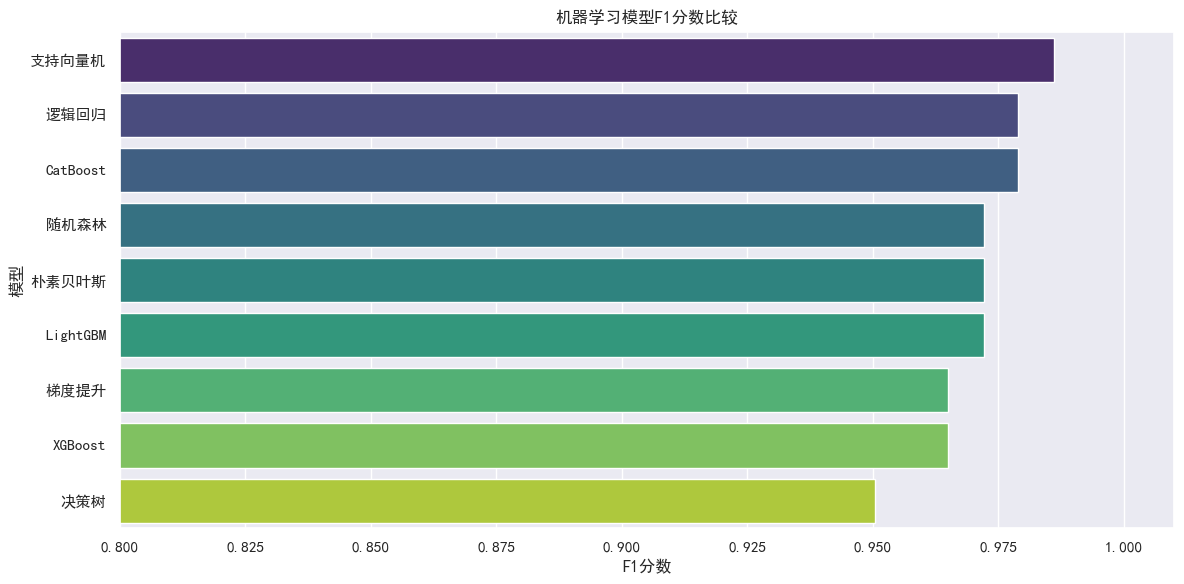

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# 使用的模型
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")
# 特别忽略lightgbm的警告
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

# --- 📌 1. 数据准备 ---
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame
X = df.drop("target", axis=1)
y = df["target"]

# 训练-测试分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 🚀 2. 模型定义 ---
models = [
    ("逻辑回归", LogisticRegression()),
    ("随机森林", RandomForestClassifier()),
    ("梯度提升", GradientBoostingClassifier()),
    ("决策树", DecisionTreeClassifier()),
    ("朴素贝叶斯", GaussianNB()),
    ("支持向量机", SVC(probability=True)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric="logloss")),
    ("LightGBM", LGBMClassifier(verbose=-1)),
    ("CatBoost", CatBoostClassifier(verbose=0))
]

# --- 📊 3. 同时运行模型并比较性能 ---
results = []

for name, model in models:
    pipe = Pipeline([
        ("scaler", StandardScaler()),  # 标准化数值特征
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results.append({
        "模型": name,
        "准确率": accuracy_score(y_test, y_pred),
        "精确率": precision_score(y_test, y_pred),
        "召回率": recall_score(y_test, y_pred),
        "F1分数": f1_score(y_test, y_pred)
    })

# 📋 将结果显示为DataFrame
df_results = pd.DataFrame(results).sort_values("F1分数", ascending=False)

# 输出到屏幕
print("📊 模型比较结果:")
print(df_results)

# 📈 可视化
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x="F1分数", y="模型", data=df_results, palette="viridis")
plt.title("机器学习模型F1分数比较")
plt.xlabel("F1分数")
plt.ylabel("模型")
plt.xlim(0.8, 1.01)
plt.tight_layout()
plt.show()

In [40]:
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto'],
    'model__degree': [2, 3, 4]  # 仅对'poly'有效
}
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

# 参数设置
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto'],
    'model__degree': [2, 3]  # 对'poly'核有效
}

# 网格搜索
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

# 最佳参数
print("🔍 最佳参数:", grid.best_params_)

# 测试集评估
y_pred = grid.predict(X_test)
print("\n📊 测试集分类结果:\n")
print(classification_report(y_test, y_pred))

🔍 最佳参数: {'model__C': 1, 'model__degree': 2, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

📊 测试集分类结果:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114




🔍 模型: 逻辑回归
ROC AUC得分: 0.9974


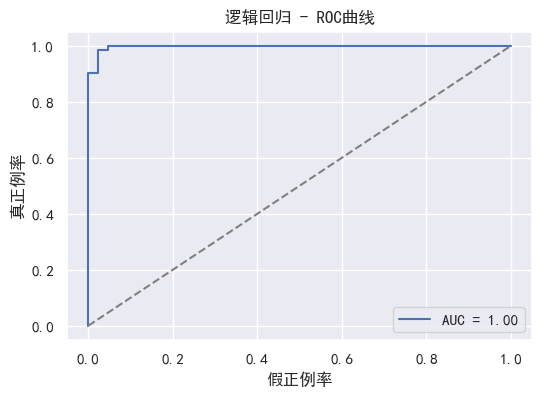

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



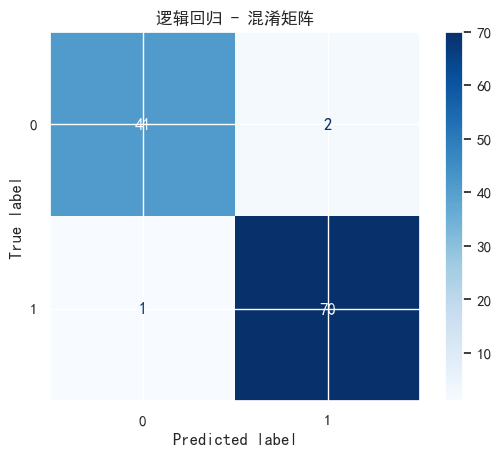

正在计算SHAP...


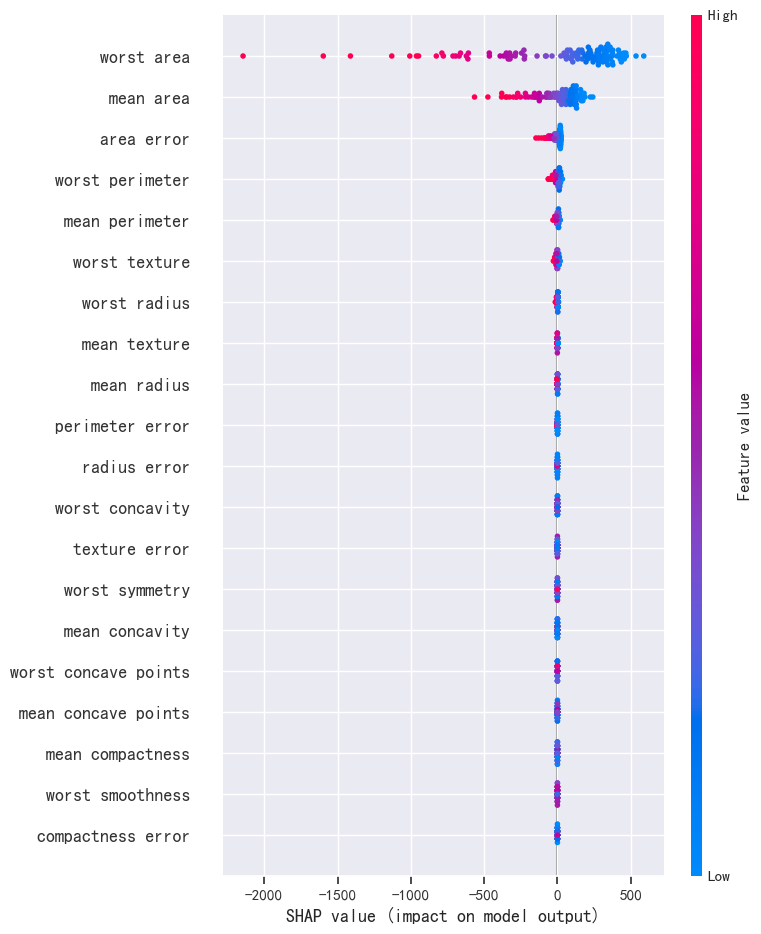


🔍 模型: 随机森林
ROC AUC得分: 0.9948


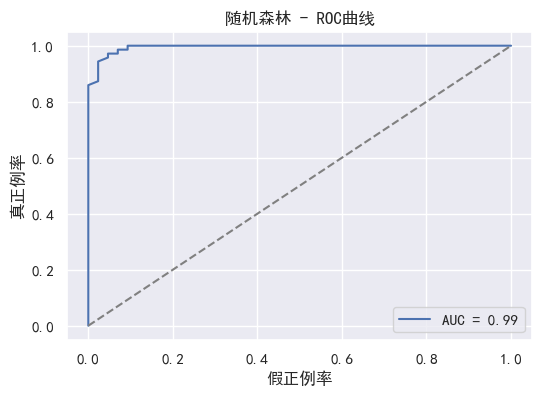

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



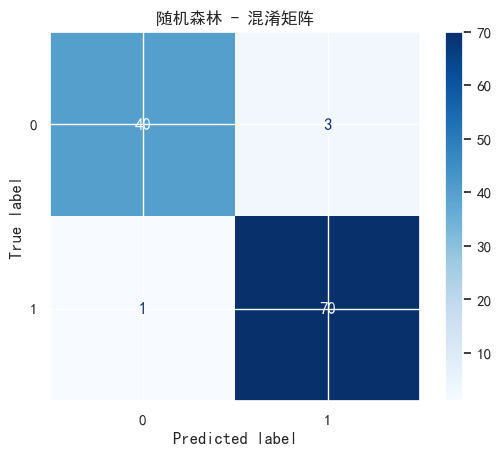

正在计算SHAP...


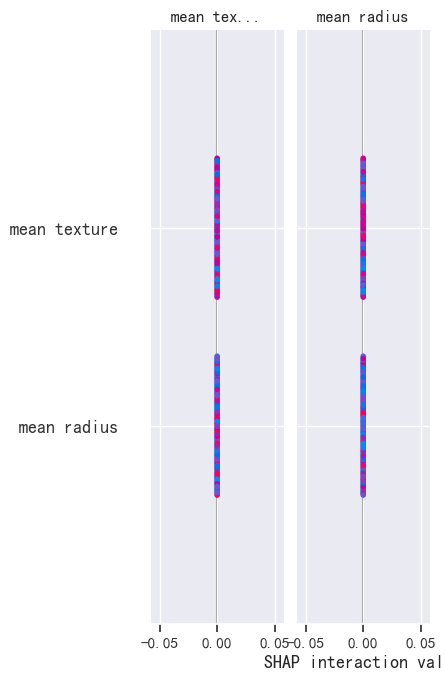


🔍 模型: 梯度提升
ROC AUC得分: 0.9944
ROC AUC得分: 0.9944


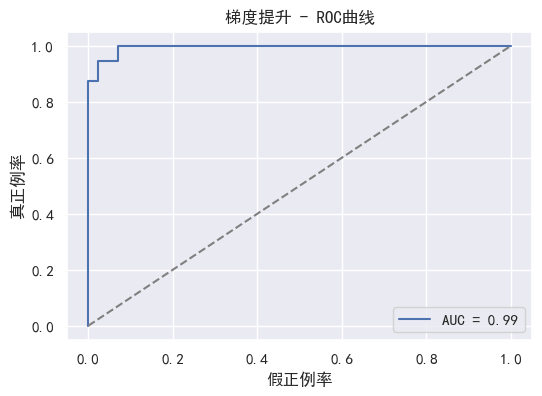

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



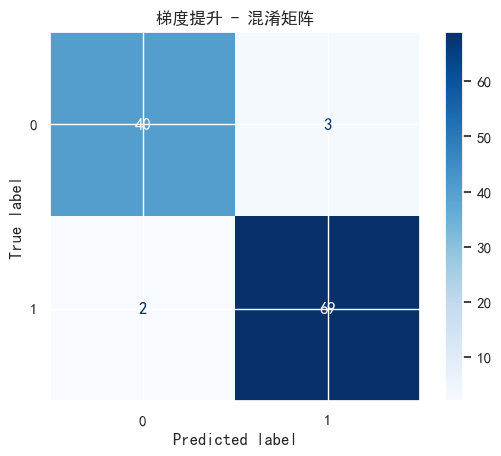

正在计算SHAP...


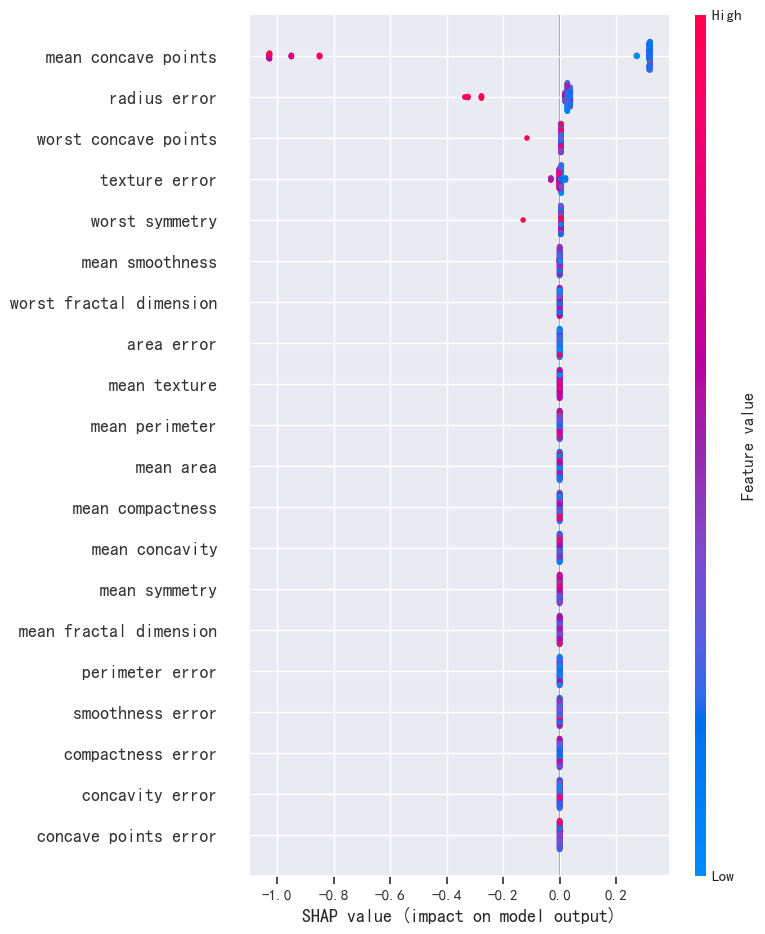


🔍 模型: 决策树
ROC AUC得分: 0.9369


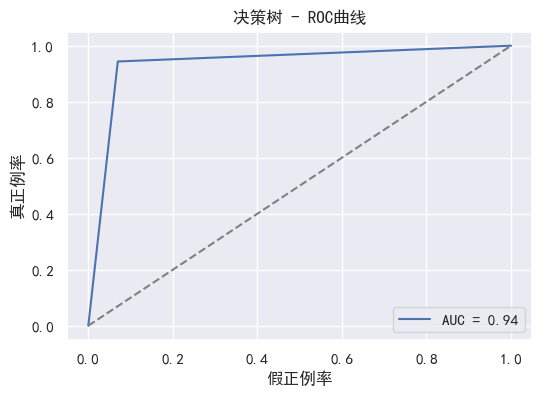

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        43
           1       0.96      0.94      0.95        71

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



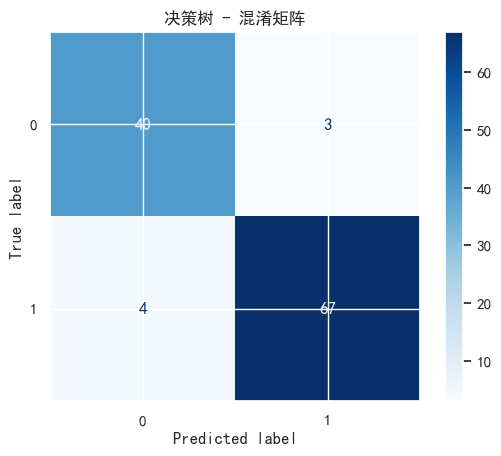

正在计算SHAP...


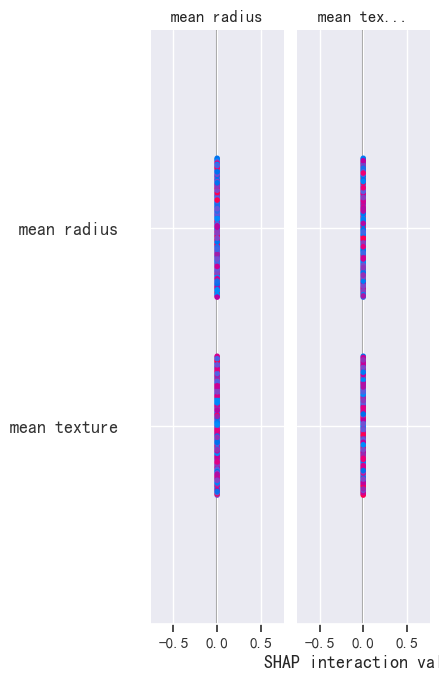


🔍 模型: 朴素贝叶斯
ROC AUC得分: 0.9974


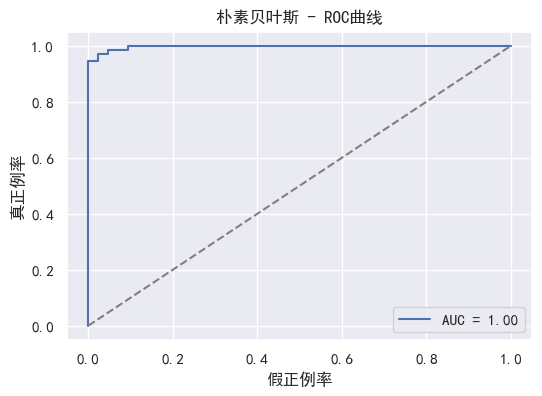

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



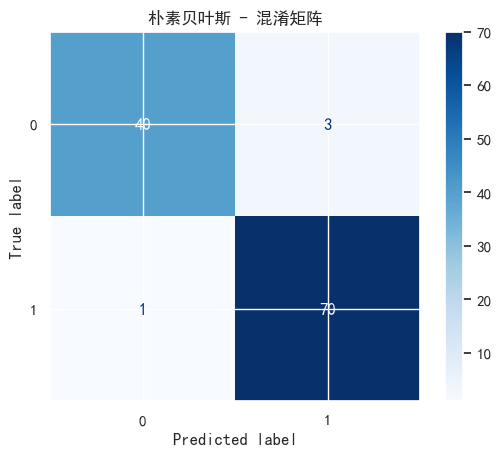

正在计算SHAP...
❌ 无法生成SHAP: The passed model is not callable and cannot be analyzed directly with the given masker! Model: GaussianNB()

🔍 模型: 支持向量机
ROC AUC得分: 0.9974


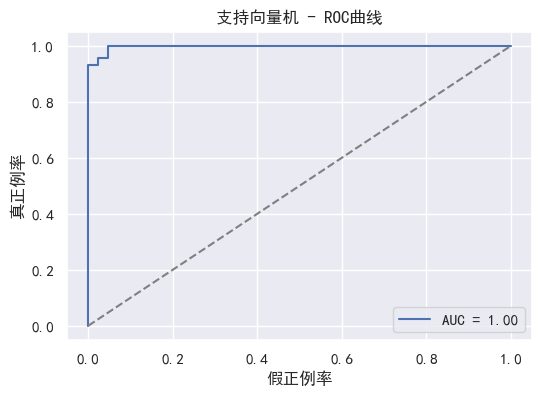

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



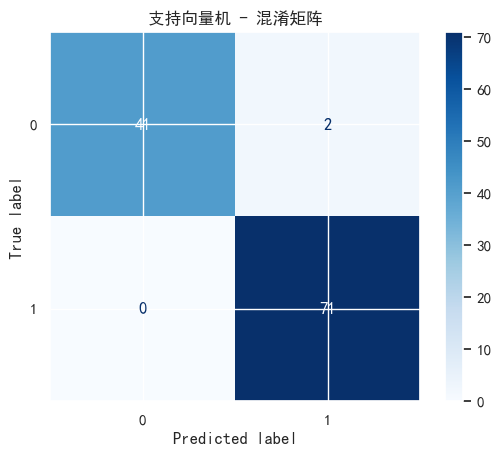

正在计算SHAP...
❌ 无法生成SHAP: The passed model is not callable and cannot be analyzed directly with the given masker! Model: SVC(probability=True)

🔍 模型: XGBoost
ROC AUC得分: 0.9908
ROC AUC得分: 0.9908


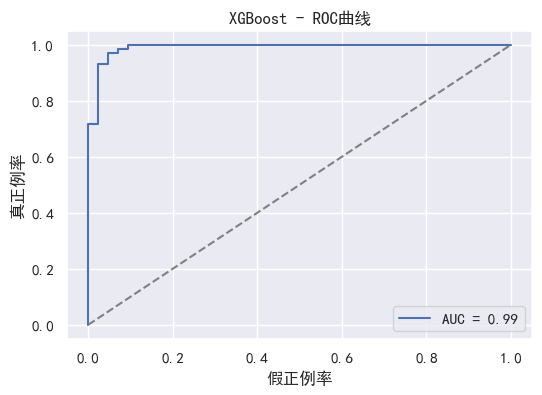

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



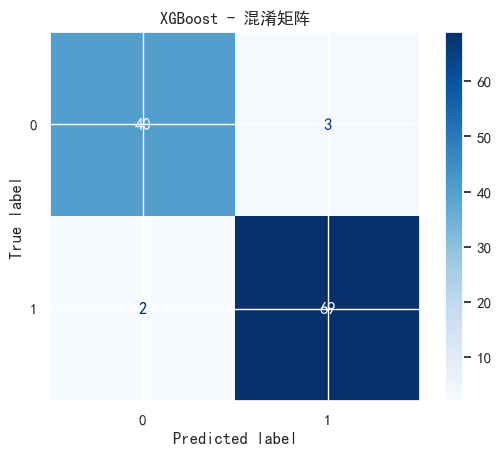

正在计算SHAP...


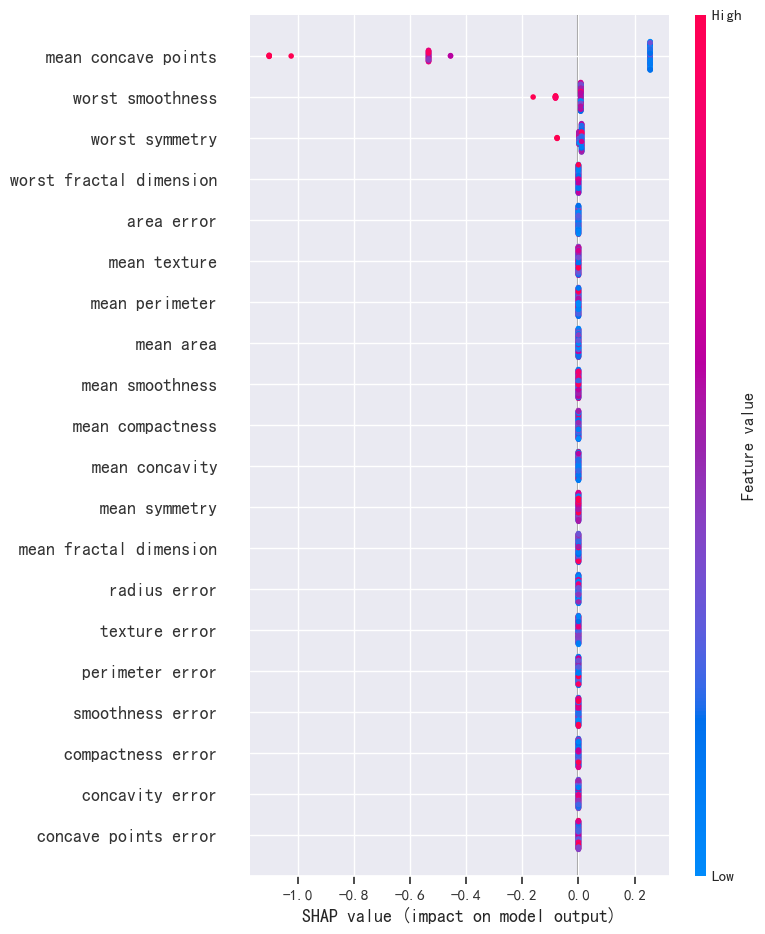


🔍 模型: LightGBM
ROC AUC得分: 0.9951


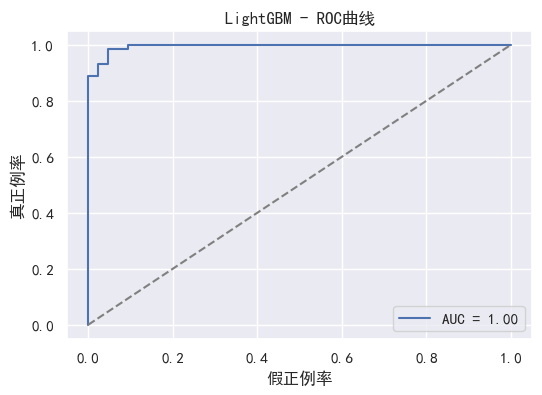

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



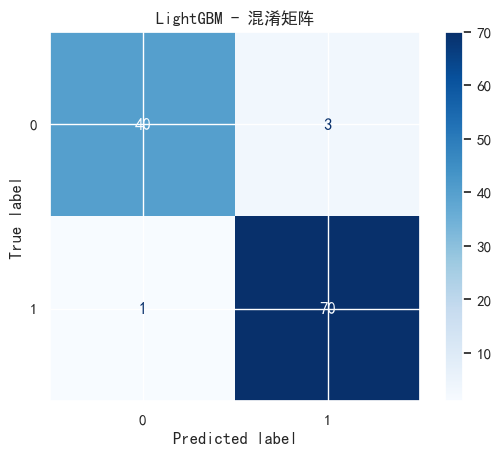

正在计算SHAP...


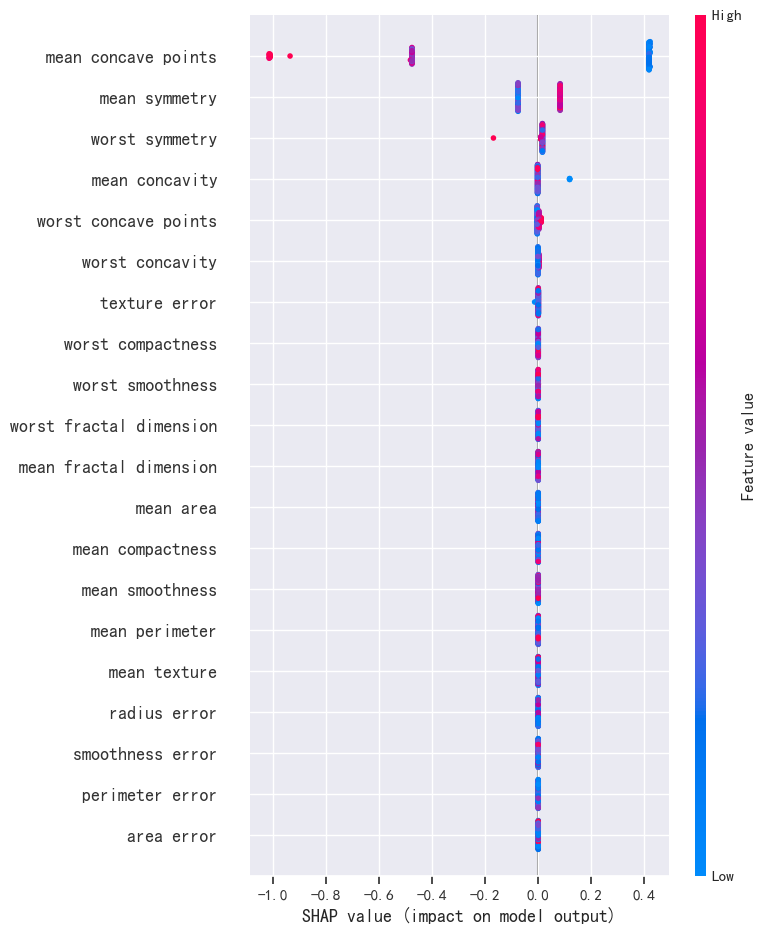


🔍 模型: CatBoost
ROC AUC得分: 0.9964
ROC AUC得分: 0.9964


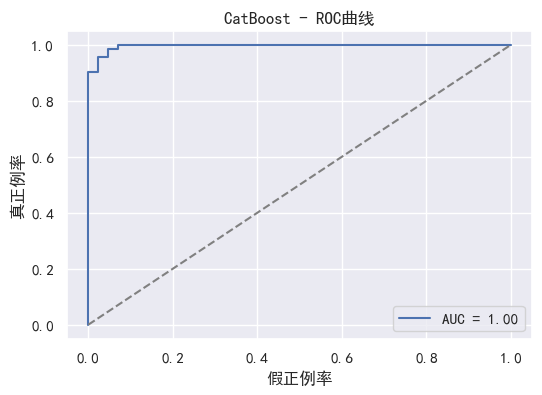

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



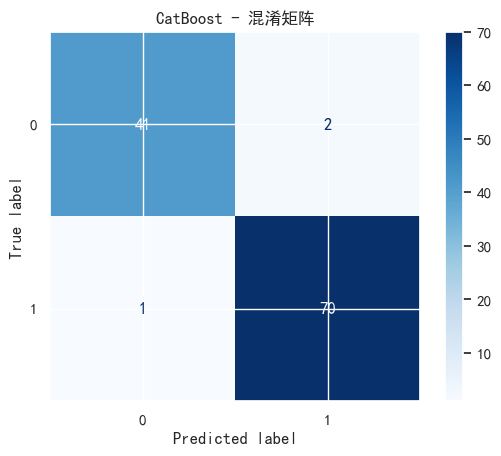

正在计算SHAP...


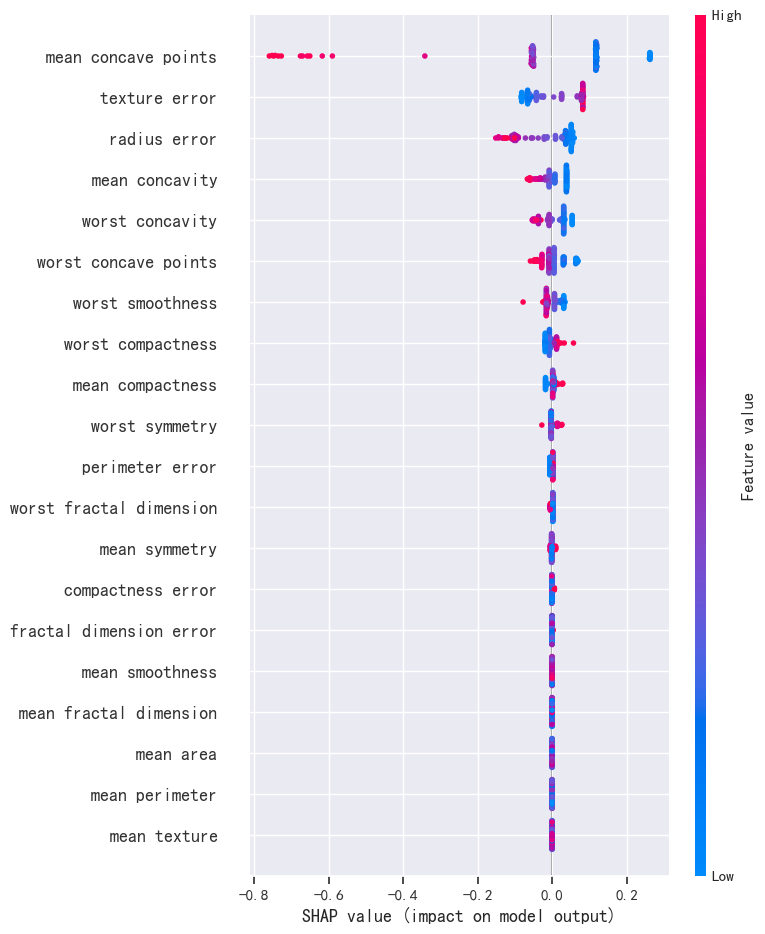

In [41]:
import shap
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 忽略lightgbm警告
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

models = {
    "逻辑回归": LogisticRegression(),
    "随机森林": RandomForestClassifier(),
    "梯度提升": GradientBoostingClassifier(),
    "决策树": DecisionTreeClassifier(),
    "朴素贝叶斯": GaussianNB(),
    "支持向量机": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "LightGBM": LGBMClassifier(verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0)
}

# --- 3. 每个模型的ROC AUC和SHAP分析 ---
for name, model in models.items():
    print(f"\n🔍 模型: {name}")
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # 🎯 ROC AUC
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC得分: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.title(f"{name} - ROC曲线")
    plt.xlabel("假正例率")
    plt.ylabel("真正例率")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 🧾 分类详细信息
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"{name} - 混淆矩阵")
    plt.show()

    # 🔍 SHAP (在树模型中效果更好)
    try:
        print("正在计算SHAP...")
        explainer = shap.Explainer(pipe.named_steps["clf"], X_train)
        shap_values = explainer(X_test)
        shap.summary_plot(shap_values, X_test, show=True)
    except Exception as e:
        print(f"❌ 无法生成SHAP: {e}")